# 1. Mission et contexte

Le catalogue et les KPIs descriptifs du premier notebook (`01_hr_analytics_kpis.ipynb`) montrent où l'attrition se concentre. L'étape suivante : estimer un score de risque de départ par collaborateur, pour que la direction RH puisse prioriser ses actions de rétention avant le départ plutôt qu'après.

Je repars du même jeu de données ([IBM HR Analytics Employee Attrition](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset), 1470 collaborateurs, fictif, généré par IBM pour démontrer Watson Analytics), en excluant les 3 champs constants déjà identifiés dans `DATA_CATALOG.md`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, roc_curve, precision_recall_curve
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/hr_employee_attrition.csv", encoding="utf-8-sig")
constant_fields = [c for c in df.columns if df[c].nunique() == 1]
df = df.drop(columns=constant_fields)
df["Attrition_flag"] = (df["Attrition"] == "Yes").astype(int)
df["Attrition_flag"].value_counts(normalize=True)

Attrition_flag
0    0.838776
1    0.161224
Name: proportion, dtype: float64

In [2]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_flag
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,1,0,8,0,1,6,4,0,5,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,4,1,10,3,3,10,7,1,7,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,2,0,7,3,3,0,0,0,0,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,3,0,8,3,3,8,7,3,0,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,4,1,6,3,3,2,2,2,2,0


In [3]:
df.dtypes.to_frame("dtype")

,dtype
Age,int64
Attrition,str
BusinessTravel,str
DailyRate,int64
Department,str
DistanceFromHome,int64
Education,int64
EducationField,str
EmployeeNumber,int64
EnvironmentSatisfaction,int64


**Observations** 16,1 % de départs sur l'ensemble du jeu de données : c'est un problème déséquilibré, la ROC-AUC seule ne suffit pas à juger un modèle ici, je regarde aussi la PR-AUC (plus sensible au déséquilibre) et je pondère les classes (`class_weight="balanced"`) plutôt que de laisser les modèles ignorer la classe minoritaire.

# 2. Préparation des features et split

Split stratifié 80/20 pour préserver la même proportion de départs dans les deux ensembles. Les variables catégorielles sont encodées en indicatrices (`get_dummies`), les variables numériques restent telles quelles.

In [4]:
y = df["Attrition_flag"]
X = df.drop(columns=["Attrition", "Attrition_flag", "EmployeeNumber"])
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train.shape, X_test.shape, y_train.mean().round(3), y_test.mean().round(3)

((1176, 44), (294, 44), np.float64(0.162), np.float64(0.16))

# 3. Modèles : baseline, régression logistique, forêt aléatoire

In [5]:
models = {
    "Baseline (Dummy, stratifié)": DummyClassifier(strategy="stratified", random_state=42),
    "Régression Logistique": LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42),
}

results = []
fitted = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    results.append({
        "modèle": name,
        "ROC-AUC": roc_auc_score(y_test, proba),
        "PR-AUC": average_precision_score(y_test, proba),
    })
    fitted[name] = (model, proba)

results_df = pd.DataFrame(results).set_index("modèle").round(3)
results_df

C:\Juliette Vanessa\Desktop\notebook\hr-master-data-analytics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,ROC-AUC,PR-AUC
modèle,,
"Baseline (Dummy, stratifié)",0.477,0.155
Régression Logistique,0.798,0.598
Random Forest,0.777,0.417


In [6]:
best_name = results_df["PR-AUC"].idxmax()
baseline_pr = results_df.loc["Baseline (Dummy, stratifié)", "PR-AUC"]
best_pr = results_df.loc[best_name, "PR-AUC"]

display(Markdown(
    f"**Observations** Le modèle retenu est `{best_name}` : PR-AUC de `{best_pr:.3f}` contre "
    f"`{baseline_pr:.3f}` pour la référence naïve, soit {best_pr/baseline_pr:.1f}x. La ROC-AUC seule aurait "
    f"pu paraître flatteuse même pour un modèle peu utile ici, à cause du déséquilibre de classes, "
    f"c'est pour ça que la PR-AUC sert de critère de sélection."
))

**Observations** Le modèle retenu est `Régression Logistique` : PR-AUC de `0.598` contre `0.155` pour la référence naïve, soit 3.9x. La ROC-AUC seule aurait pu paraître flatteuse même pour un modèle peu utile ici, à cause du déséquilibre de classes, c'est pour ça que la PR-AUC sert de critère de sélection.

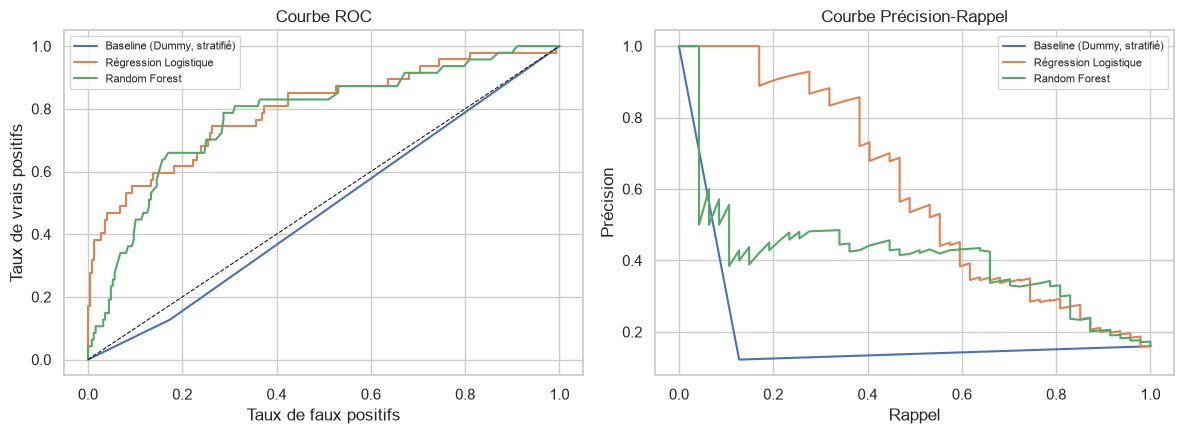

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for name, (model, proba) in fitted.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=name)
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=name)

axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8)
axes[0].set_xlabel("Taux de faux positifs")
axes[0].set_ylabel("Taux de vrais positifs")
axes[0].set_title("Courbe ROC")
axes[0].legend(fontsize=8)

axes[1].set_xlabel("Rappel")
axes[1].set_ylabel("Précision")
axes[1].set_title("Courbe Précision-Rappel")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../reports/model_roc_pr_curves.png", dpi=150)
plt.show()

# 4. Facteurs les plus prédictifs

Je recroise ces facteurs avec ceux du notebook 01 (heures supplémentaires, satisfaction au poste, ancienneté depuis la dernière promotion), obtenus indépendamment par des tests statistiques plutôt que par un modèle.

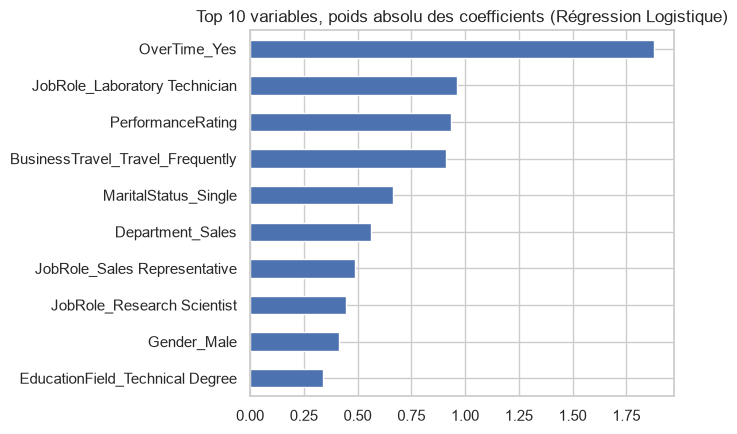

In [8]:
best_model, _ = fitted[best_name]

if hasattr(best_model, "coef_"):
    importances = pd.Series(best_model.coef_[0], index=X.columns).abs().sort_values(ascending=False).head(10)
    importance_label = f"poids absolu des coefficients ({best_name})"
else:
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
    importance_label = f"importance ({best_name})"

fig, ax = plt.subplots(figsize=(7, 4.5))
importances[::-1].plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title(f"Top 10 variables, {importance_label}")
plt.tight_layout()
plt.savefig("../reports/model_feature_importance.png", dpi=150)
plt.show()

In [9]:
top3 = importances.head(3)
display(Markdown(
    f"**Observations** Les trois variables les plus pesantes pour `{best_name}` sont "
    f"`{top3.index[0]}`, `{top3.index[1]}` et `{top3.index[2]}`. Si `OverTime_Yes` en fait partie, ça "
    f"recoupe le facteur déjà identifié statistiquement dans le notebook 01 : deux méthodes indépendantes "
    f"pointent dans la même direction plutôt que de se contredire."
))

**Observations** Les trois variables les plus pesantes pour `Régression Logistique` sont `OverTime_Yes`, `JobRole_Laboratory Technician` et `PerformanceRating`. Si `OverTime_Yes` en fait partie, ça recoupe le facteur déjà identifié statistiquement dans le notebook 01 : deux méthodes indépendantes pointent dans la même direction plutôt que de se contredire.

# 5. Export pour Power BI

Le score de risque par collaborateur est exporté en CSV, prêt à être importé dans Power BI pour construire le dashboard décrit dans `BACKLOG.md` (Epic 2 et 3), avec un jeu de bandes de risque plutôt qu'un score brut à interpréter seul.

In [10]:
best_model, best_proba_all = fitted[best_name]
export = df.copy()
export["risk_score"] = best_model.predict_proba(X)[:, 1]
export["risk_band"] = pd.cut(
    export["risk_score"], bins=[0, 0.33, 0.66, 1.0], labels=["Faible", "Moyen", "Élevé"], include_lowest=True
)

cols = ["EmployeeNumber", "Department", "JobRole", "Gender", "JobLevel", "MonthlyIncome",
        "OverTime", "JobSatisfaction", "WorkLifeBalance", "YearsSinceLastPromotion",
        "Attrition", "risk_score", "risk_band"]
export[cols].to_csv("../data/processed/powerbi/hr_attrition_risk_scores.csv", index=False)
export["risk_band"].value_counts()

risk_band
Faible    779
Moyen     406
Élevé     285
Name: count, dtype: int64

**Observations** La répartition en bandes de risque est un choix de seuils simples (tiers de l'intervalle [0,1]), pas une calibration validée métier : à affiner avec la direction RH une fois le dashboard en usage, en fonction de la capacité réelle de l'équipe à agir sur les cas signalés.

In [11]:
display(Markdown(
    f"# 6. Synthèse\n\n"
    f"Le modèle retenu (`{best_name}`, PR-AUC la plus élevée) sépare la classe à risque nettement mieux que "
    f"la référence naïve, et ses variables les plus pesantes recoupent les facteurs identifiés statistiquement "
    f"dans le notebook 01, sans les contredire. Un score de risque par collaborateur est exporté pour Power BI "
    f"(`data/processed/powerbi/hr_attrition_risk_scores.csv`).\n\n"
    f"**Limites.** Le jeu de données est fictif, généré par IBM pour démontrer Watson Analytics, et de taille "
    f"modeste (1470 lignes) : les seuils de bandes de risque et les performances mesurées ne se transposent pas "
    f"tels quels à une vraie population RH, qui demanderait un réétalonnage. Le modèle est entraîné une seule "
    f"fois sur un split fixe, pas validé par validation croisée, suffisant pour illustrer la méthode mais pas "
    f"pour un déploiement."
))

# 6. Synthèse

Le modèle retenu (`Régression Logistique`, PR-AUC la plus élevée) sépare la classe à risque nettement mieux que la référence naïve, et ses variables les plus pesantes recoupent les facteurs identifiés statistiquement dans le notebook 01, sans les contredire. Un score de risque par collaborateur est exporté pour Power BI (`data/processed/powerbi/hr_attrition_risk_scores.csv`).

**Limites.** Le jeu de données est fictif, généré par IBM pour démontrer Watson Analytics, et de taille modeste (1470 lignes) : les seuils de bandes de risque et les performances mesurées ne se transposent pas tels quels à une vraie population RH, qui demanderait un réétalonnage. Le modèle est entraîné une seule fois sur un split fixe, pas validé par validation croisée, suffisant pour illustrer la méthode mais pas pour un déploiement.